# sde_model.ipynb

Initial model for the governing SDE. Keep in mind layers are low, since this is a "hackathon" project.

### Initial instructions

- Make sure to have a ```.venv``` set up. Install ```torch```, ```torchsde```, ```numpy```, ```matplotlib```. 

#### Package imports

In [122]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

Priority: mps (Apple Silicon) > CUDA > CPU

In [123]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


#### Synthetic data generation (just in case)

In [124]:
def generate_synthetic_flight(num_steps=100):
    t = torch.linspace(0, 1, num_steps).to(device)
    # Synthetic ground truth: Linear fuel burn, constant velocity, slight climb
    # Shape: [Time, 3] -> [Fuel, Velocity, Altitude]
    fuel = 1.0 - 0.2 * t 
    velocity = 0.8 + 0.05 * torch.sin(5 * t)
    altitude = 0.5 + 0.3 * t
    
    y_true = torch.stack([fuel, velocity, altitude], dim=-1).unsqueeze(1) # [T, Batch=1, 3]
    return t, y_true

#### Load flight tensors

In [125]:
def load_flight_tensors(file_path="../Datasets/flight_data.pt", device="cpu"):
    data = torch.load(file_path, map_location=device)
    
    t = data['t'].to(device)
    y_true = data['y_true'].to(device)
    stats = data['stats']
    
    return t, y_true, stats

#### NeuralSDE class

In [126]:
class NeuralSDE(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        # Input: [Fuel, Velocity, Altitude]
        self.input_dim = 3
        
        # Drift (deterministic)
        self.f_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3)
        )
        nn.init.constant_(self.f_net[-1].weight, 0.1),
        nn.init.constant_(self.f_net[-1].bias, 0.0)
        
        # Diffusion (stochastic)
        self.g_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
            nn.Sigmoid() # Standard dev must be positive
        )

        # 1. Define the weight initialization logic
        def init_weights(m):
            if isinstance(m, nn.Linear):
                # Apply Xavier/Glorot uniform initialization
                torch.nn.init.xavier_uniform_(m.weight)
                # Small constant bias to keep neurons "alive"
                m.bias.data.fill_(0.01)

        # 2. Apply it to your networks at the end of __init__
        self.f_net.apply(init_weights)
        self.g_net.apply(init_weights)

        
        # Diffusion final layer (-2 because -1 is the Sigmoid activation)
        nn.init.constant_(self.g_net[-2].weight, 0.001)
        nn.init.constant_(self.g_net[-2].bias, 0.0)
        
        self.noise_type = "diagonal"
        self.sde_type = "ito"


    def f(self, t, y):
        # y shape: [batch_size, 3]
        res = self.f_net(y)
        # Physical constraint: Fuel (idx 0) can only decrease
        fuel_gate = -torch.nn.functional.softplus(res[:, 0:1])
        return torch.cat([fuel_gate, res[:, 1:]], dim=-1)

    def g(self, t, y):
        # y shape: [batch_size, 3]
        return self.g_net(y)

#### Training

In [127]:
def train_step(model, batch_y0, batch_t, batch_y_true, optimizer, is_lbfgs=False):
    model.train()

    def closure():
        optimizer.zero_grad()    
        """
        Integrate the SDE
        # batch_y0: Initial state [Fuel, Altitude]
        # batch_t: Time steps for the flight duration
        """
        pred_y = torchsde.sdeint_adjoint(model, batch_y0, batch_t, dt=0.01, method='euler')
    
        """Loss Function 
        MSE for trajectories
        """
        loss = nn.MSELoss()(pred_y, batch_y_true)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Bound the trajectory, planes don't work in outer space.
        return loss
    
    if is_lbfgs:
        loss = optimizer.step(closure)
    else:
        loss = closure()
        optimizer.step()
    
    return loss.item()


def train_model(model, t, y_true, epochs=500, lbfgs_start_epoch=480):
    # 1. Initialize Optimizers
    # AdamW for the bulk of training
    optimizer_adam = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

    
    # LBFGS for fine-tuning
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(), 
        lr=0.1, 
        max_iter=20, 
        history_size=10, 
        line_search_fn="strong_wolfe"
    )
    
    """
    Optimizer selection:
    - We use AdamW as a way to begin our training, and to carry us through most of the iterations
    - We later refine using LBFGS, which will take more into account the actual geometry (second order derivatives) of the problem
    """

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, 'min', patience=5, factor=0.5) # If our loss doesn't improve in 5 epochs, we cut the learning rate
    
    # Ensure data is on the correct device
    y0 = y_true[0].to(device)
    t = t.to(device)
    y_true = y_true.to(device)

    for epoch in range(1, epochs + 1):
        model.train()

        if epoch < lbfgs_start_epoch:
            "AdamW step"
            loss = train_step(model, y0, t, y_true, optimizer_adam)
        else:
            "LBFGS step"
            loss = train_step(model, y0, t, y_true, optimizer_lbfgs, True)
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {loss:.6f} | Mode: {'AdamW' if epoch < lbfgs_start_epoch else 'LBFGS'}")

    return model

#### Actually running the code

In [128]:
t, y_true, stats = load_flight_tensors("../Data/Datasets/flight_data.pt", device)
model = NeuralSDE(hidden_dim=64).to(device)
trained_model = train_model(model, t, y_true, epochs=500)

Epoch 001 | Loss: 0.379712 | Mode: AdamW
Epoch 020 | Loss: 0.230733 | Mode: AdamW
Epoch 040 | Loss: 0.151598 | Mode: AdamW
Epoch 060 | Loss: 0.113738 | Mode: AdamW
Epoch 080 | Loss: 0.068926 | Mode: AdamW
Epoch 100 | Loss: 0.059891 | Mode: AdamW
Epoch 120 | Loss: 0.047604 | Mode: AdamW
Epoch 140 | Loss: 0.044153 | Mode: AdamW
Epoch 160 | Loss: 0.040809 | Mode: AdamW
Epoch 180 | Loss: 0.039746 | Mode: AdamW
Epoch 200 | Loss: 0.037276 | Mode: AdamW
Epoch 220 | Loss: 0.037153 | Mode: AdamW
Epoch 240 | Loss: 0.035626 | Mode: AdamW
Epoch 260 | Loss: 0.034940 | Mode: AdamW
Epoch 280 | Loss: 0.034991 | Mode: AdamW
Epoch 300 | Loss: 0.034110 | Mode: AdamW
Epoch 320 | Loss: 0.035062 | Mode: AdamW
Epoch 340 | Loss: 0.033645 | Mode: AdamW
Epoch 360 | Loss: 0.032118 | Mode: AdamW
Epoch 380 | Loss: 0.033454 | Mode: AdamW
Epoch 400 | Loss: 0.031859 | Mode: AdamW
Epoch 420 | Loss: 0.032942 | Mode: AdamW
Epoch 440 | Loss: 0.031389 | Mode: AdamW
Epoch 460 | Loss: 0.032357 | Mode: AdamW
Epoch 480 | Loss

#### Uncertainty cone (for display)

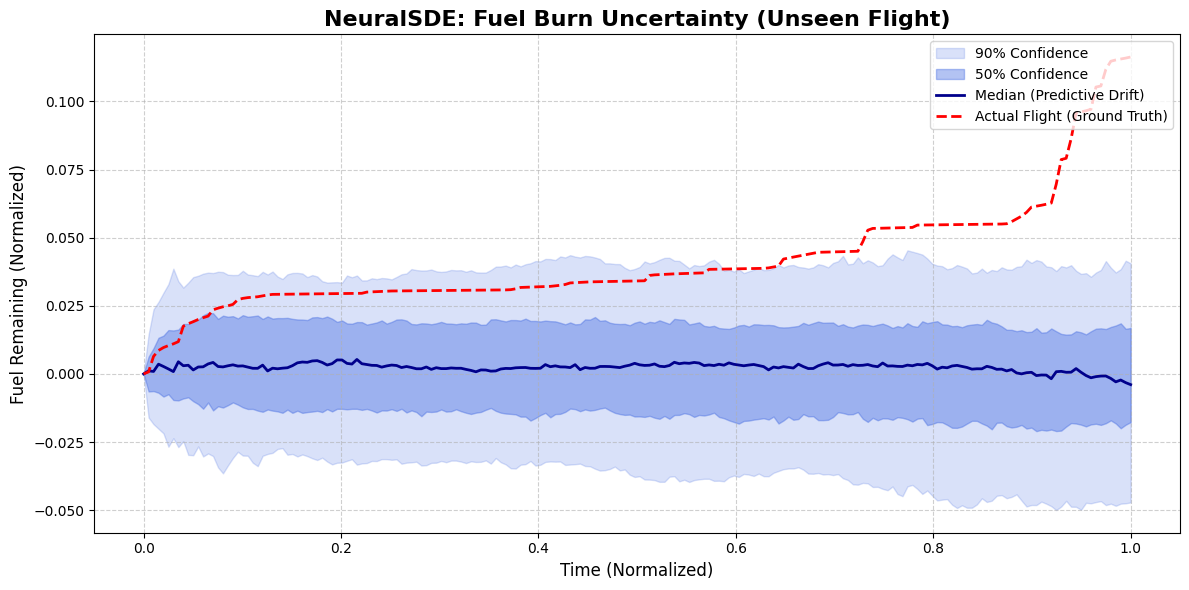

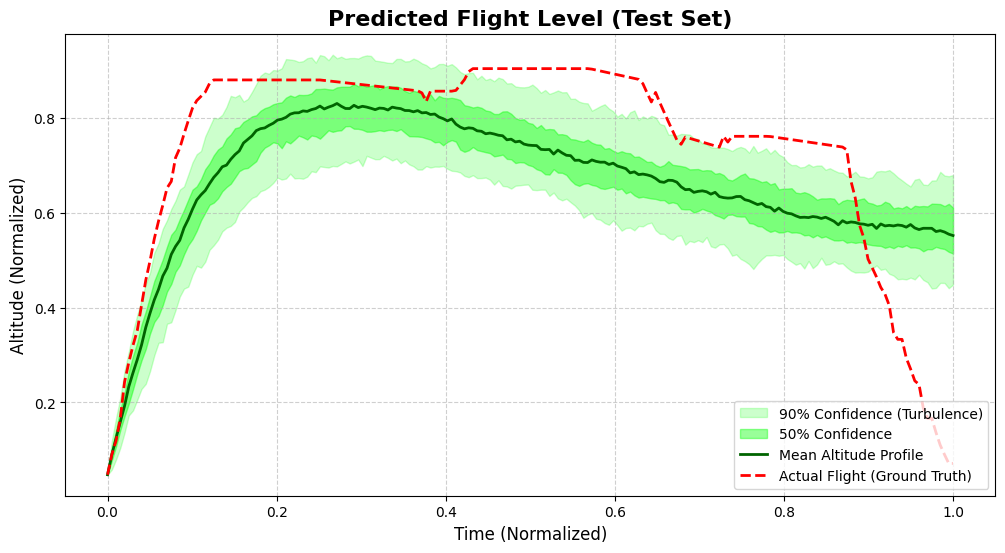

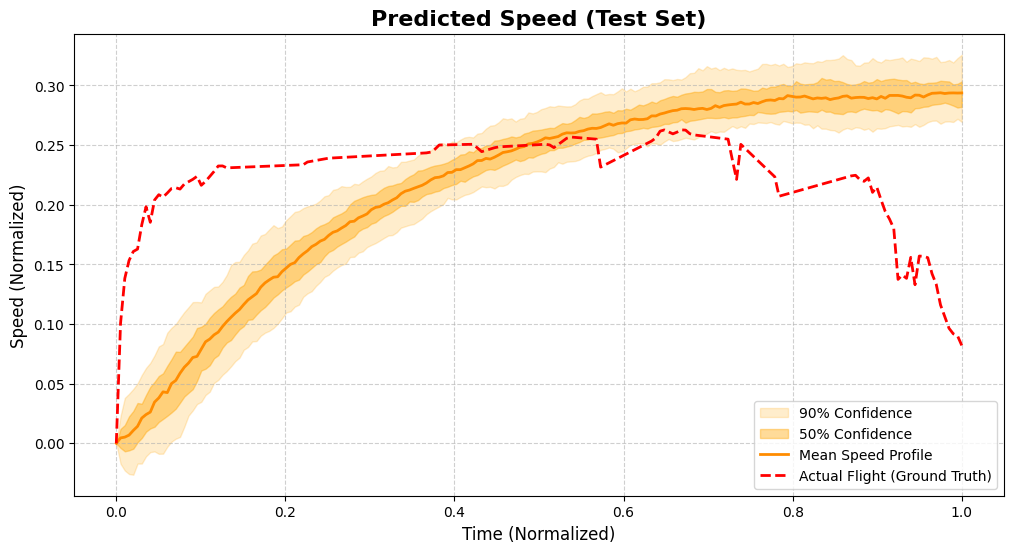

In [129]:
# 1. Load the unseen TEST dataset
t_test, y_true_test, stats_test = load_flight_tensors("../Data/Datasets/flight_data_test.pt", device)

def generate_uncertainty_cone(model, y0, t_span, num_simulations=100):
    model.eval()
    with torch.no_grad():
        # y0 comes in as shape [1, 3], repeat for Monte Carlo sampling
        y0_expanded = y0.repeat(num_simulations, 1).to(device)
        t_span = t_span.to(device)
        
        # All 100 flights simulated in one GPU pass
        trajectories = torchsde.sdeint(model, y0_expanded, t_span, method='euler')
        
    return trajectories.cpu() # Move back to CPU for plotting with Matplotlib


def plot_fuel_fan_chart(trajectories, t_span, y_true, title="Probabilistic Fuel Consumption"):
    # Extract Fuel (Index 0)
    fuel_data = trajectories[:, :, 0].cpu().numpy()
    t = t_span.cpu().numpy()
    
    # Ground truth (Index 0) from test set [Time, Batch=1, Features]
    true_fuel = y_true[:, 0, 0].cpu().numpy()

    median = np.median(fuel_data, axis=1)
    p5, p25 = np.percentile(fuel_data, 5, axis=1), np.percentile(fuel_data, 25, axis=1)
    p75, p95 = np.percentile(fuel_data, 75, axis=1), np.percentile(fuel_data, 95, axis=1)

    plt.figure(figsize=(12, 6), dpi=100)
    
    plt.fill_between(t, p5, p95, color='royalblue', alpha=0.2, label='90% Confidence')
    plt.fill_between(t, p25, p75, color='royalblue', alpha=0.4, label='50% Confidence')
    plt.plot(t, median, color='darkblue', lw=2, label='Median (Predictive Drift)')
    
    # Plot Ground Truth
    plt.plot(t, true_fuel, color='red', lw=2, linestyle='--', label='Actual Flight (Ground Truth)')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Time (Normalized)", fontsize=12)
    plt.ylabel("Fuel Remaining (Normalized)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()


def plot_altitude_fan_chart(trajectories, t_span, y_true, title="Predicted Flight Level (Test Set)"):
    # Extract Altitude (Index 2)
    alt_data = trajectories[:, :, 2].cpu().numpy()
    t = t_span.cpu().numpy()
    
    # Ground truth (Index 2)
    true_alt = y_true[:, 0, 2].cpu().numpy()

    median = np.median(alt_data, axis=1)
    p5, p25 = np.percentile(alt_data, 5, axis=1), np.percentile(alt_data, 25, axis=1)
    p75, p95 = np.percentile(alt_data, 75, axis=1), np.percentile(alt_data, 95, axis=1)

    plt.figure(figsize=(12, 6), dpi=100)
    plt.fill_between(t, p5, p95, color='lime', alpha=0.2, label='90% Confidence (Turbulence)')
    plt.fill_between(t, p25, p75, color='lime', alpha=0.4, label='50% Confidence')
    plt.plot(t, median, color='darkgreen', lw=2, label='Mean Altitude Profile')
    
    # Plot Ground Truth
    plt.plot(t, true_alt, color='red', lw=2, linestyle='--', label='Actual Flight (Ground Truth)')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Time (Normalized)", fontsize=12)
    plt.ylabel("Altitude (Normalized)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')
    plt.show()


def plot_speed_fan_chart(trajectories, t_span, y_true, title="Predicted Speed (Test Set)"): 
    # Extract Speed (Index 1)
    speed_data = trajectories[:, :, 1].cpu().numpy()
    t = t_span.cpu().numpy()
    
    # Ground truth (Index 1)
    true_speed = y_true[:, 0, 1].cpu().numpy()

    median = np.median(speed_data, axis=1)
    p5, p25 = np.percentile(speed_data, 5, axis=1), np.percentile(speed_data, 25, axis=1)
    p75, p95 = np.percentile(speed_data, 75, axis=1), np.percentile(speed_data, 95, axis=1)

    plt.figure(figsize=(12, 6), dpi=100)
    plt.fill_between(t, p5, p95, color='orange', alpha=0.2, label='90% Confidence')
    plt.fill_between(t, p25, p75, color='orange', alpha=0.4, label='50% Confidence')
    plt.plot(t, median, color='darkorange', lw=2, label='Mean Speed Profile')
    
    # Plot Ground Truth
    plt.plot(t, true_speed, color='red', lw=2, linestyle='--', label='Actual Flight (Ground Truth)')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Time (Normalized)", fontsize=12)
    plt.ylabel("Speed (Normalized)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')
    plt.show()

# --- Execution ---
num_scenarios = 100 

# Extract the initial state from the test set (shape: [1, 3])
y0_test = y_true_test[0]

# Generate trajectories based purely on the initial state of the test flight
trajectories_test = generate_uncertainty_cone(model, y0_test, t_test, num_simulations=num_scenarios)

# Plot everything, passing in the test ground truth so it gets overlaid
plot_fuel_fan_chart(trajectories_test, t_test, y_true_test, title="NeuralSDE: Fuel Burn Uncertainty (Unseen Flight)")
plot_altitude_fan_chart(trajectories_test, t_test, y_true_test)
plot_speed_fan_chart(trajectories_test, t_test, y_true_test)